In [3]:
!pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load dataset using a raw string (r"...")
df = pd.read_csv(r"C:\new location one\OneDrive\Documents\supply chain project\Inventory Supply Chain Dataset.csv")

In [13]:
df.head()

,Date,Region,Category,Supplier,Warehouse,Order Status,Units Sold,Inventory Level,Transportation Cost,Order Accuracy,Lead Time (Days),Backorder,Cost of Goods Sold (COGS),Average Inventory,Warehouse Capacity
0,14-01-2020,North,Accessories,Supplier A,Warehouse 1,Fulfilled,302,2124,1103.838324,True,9,False,37820.05240,2048.0,5037
1,15-11-2020,East,Furniture,Supplier D,Warehouse 2,Fulfilled,741,1972,13163.007660,True,11,False,54396.17369,1213.0,9216
2,16-04-2020,East,Furniture,Supplier C,Warehouse 2,Fulfilled,940,454,9872.294126,True,17,False,24217.45462,1160.5,7699
3,17-04-2020,South,Accessories,Supplier D,Warehouse 2,Canceled,589,1867,4547.589932,True,3,False,38919.08005,3364.5,9271
4,18-04-2020,North,Accessories,Supplier C,Warehouse 2,Fulfilled,964,4862,11994.042310,True,21,False,59204.50683,3063.0,5828


In [14]:
df.shape

(1200, 15)

In [15]:
df.columns

Index(['Date', 'Region', 'Category', 'Supplier', 'Warehouse', 'Order Status',
       'Units Sold', 'Inventory Level', 'Transportation Cost',
       'Order Accuracy', 'Lead Time (Days)', 'Backorder',
       'Cost of Goods Sold (COGS)', 'Average Inventory', 'Warehouse Capacity'],
      dtype='object')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       1200 non-null   object 
 1   Region                     1200 non-null   object 
 2   Category                   1200 non-null   object 
 3   Supplier                   1200 non-null   object 
 4   Warehouse                  1200 non-null   object 
 5   Order Status               1200 non-null   object 
 6   Units Sold                 1200 non-null   int64  
 7   Inventory Level            1200 non-null   int64  
 8   Transportation Cost        1200 non-null   float64
 9   Order Accuracy             1200 non-null   bool   
 10  Lead Time (Days)           1200 non-null   int64  
 11  Backorder                  1200 non-null   bool   
 12  Cost of Goods Sold (COGS)  1200 non-null   float64
 13  Average Inventory          1200 non-null   float

In [17]:
df.isnull().sum()

Date                         0
Region                       0
Category                     0
Supplier                     0
Warehouse                    0
Order Status                 0
Units Sold                   0
Inventory Level              0
Transportation Cost          0
Order Accuracy               0
Lead Time (Days)             0
Backorder                    0
Cost of Goods Sold (COGS)    0
Average Inventory            0
Warehouse Capacity           0
dtype: int64

In [18]:
df_clean = df.copy()

In [19]:
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")

df_clean["Date"].head()

C:\Users\krith\AppData\Local\Temp\ipykernel_13500\1200863364.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")


0   2020-01-14
1   2020-11-15
2   2020-04-16
3   2020-04-17
4   2020-04-18
Name: Date, dtype: datetime64[ns]

In [20]:
df_clean.duplicated().sum()

np.int64(0)

In [21]:
df_clean = df_clean.drop_duplicates()

In [22]:
df_clean.isnull().sum()

Date                         0
Region                       0
Category                     0
Supplier                     0
Warehouse                    0
Order Status                 0
Units Sold                   0
Inventory Level              0
Transportation Cost          0
Order Accuracy               0
Lead Time (Days)             0
Backorder                    0
Cost of Goods Sold (COGS)    0
Average Inventory            0
Warehouse Capacity           0
dtype: int64

In [23]:
df_clean.describe()

,Date,Units Sold,Inventory Level,Transportation Cost,Lead Time (Days),Cost of Goods Sold (COGS),Average Inventory,Warehouse Capacity
count,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2023-03-26 23:19:12,533.892500,2530.473333,7723.518494,15.739167,59370.480017,2529.588333,7425.831667
min,2020-01-14 00:00:00,50.000000,101.000000,509.098991,1.000000,1415.613541,235.000000,5002.000000
25%,2022-07-14 18:00:00,298.000000,1261.750000,4145.882050,8.000000,22982.367025,1843.000000,6116.500000
50%,2023-05-11 12:00:00,529.000000,2623.500000,7759.647979,16.000000,47773.376750,2496.500000,7427.000000
75%,2024-03-06 06:00:00,777.000000,3726.250000,11154.018832,23.000000,88006.544317,3240.125000,8662.250000
max,2024-12-31 00:00:00,999.000000,4999.000000,14997.814050,29.000000,190841.495400,4863.500000,9995.000000
std,NaN,275.469524,1416.945265,4202.727652,8.442187,44542.532052,1000.512796,1460.827133


In [24]:
for col in ["Region", "Category", "Supplier", "Warehouse", "Order Status", "Backorder"]:
    print("\n", col)
    print(df_clean[col].value_counts())


 Region
Region
North    317
West     317
East     284
South    282
Name: count, dtype: int64

 Category
Category
Electronics    314
Clothing       311
Furniture      306
Accessories    269
Name: count, dtype: int64

 Supplier
Supplier
Supplier A    312
Supplier B    310
Supplier D    303
Supplier C    275
Name: count, dtype: int64

 Warehouse
Warehouse
Warehouse 1    403
Warehouse 3    403
Warehouse 2    394
Name: count, dtype: int64

 Order Status
Order Status
Fulfilled    838
Pending      248
Canceled     114
Name: count, dtype: int64

 Backorder
Backorder
False    1084
True      116
Name: count, dtype: int64


In [25]:
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())

Rows: 1200
Columns: 15
Missing values: 0
Duplicate rows: 0


In [26]:
df_clean.to_csv("Supply_Chain_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


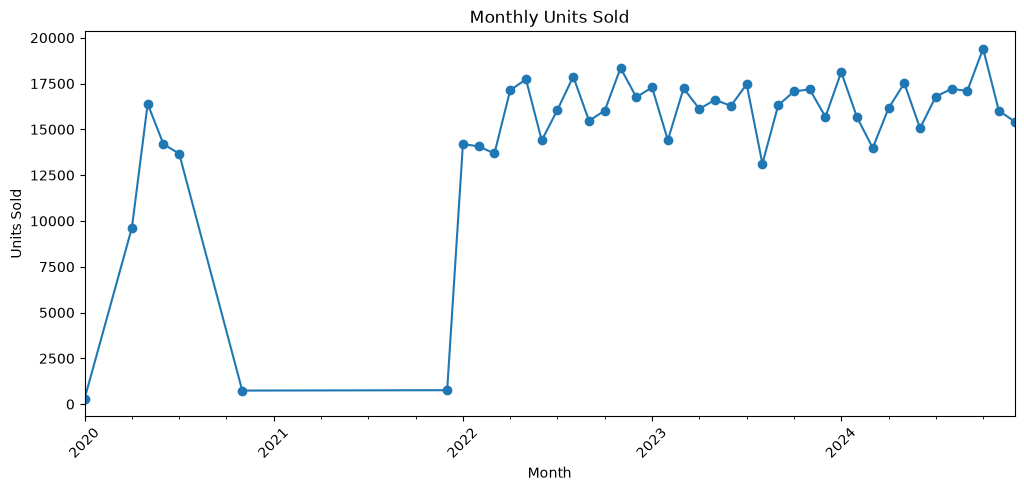

In [27]:
monthly_sales = df_clean.groupby(
    df_clean["Date"].dt.to_period("M")
)["Units Sold"].sum()

monthly_sales.plot(kind="line", figsize=(12, 5), marker="o")

plt.title("Monthly Units Sold")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

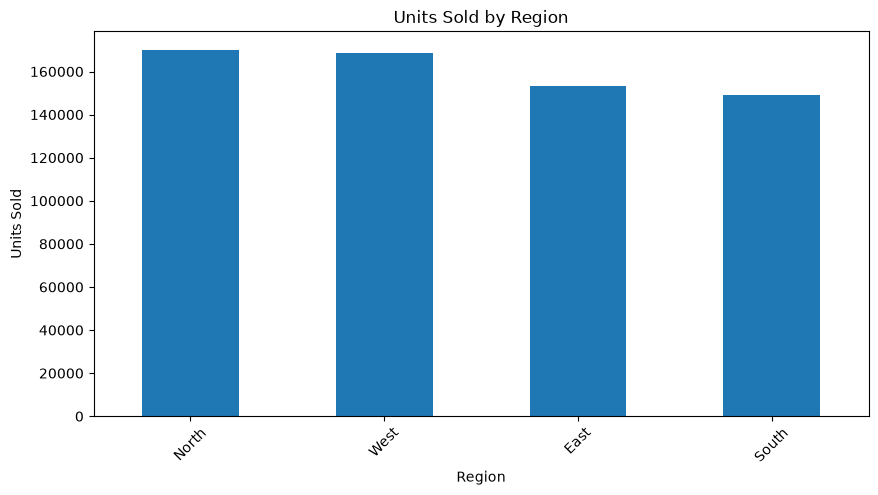

In [28]:
region_sales = df_clean.groupby("Region")["Units Sold"].sum().sort_values(ascending=False)

region_sales.plot(kind="bar", figsize=(10, 5))

plt.title("Units Sold by Region")
plt.xlabel("Region")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

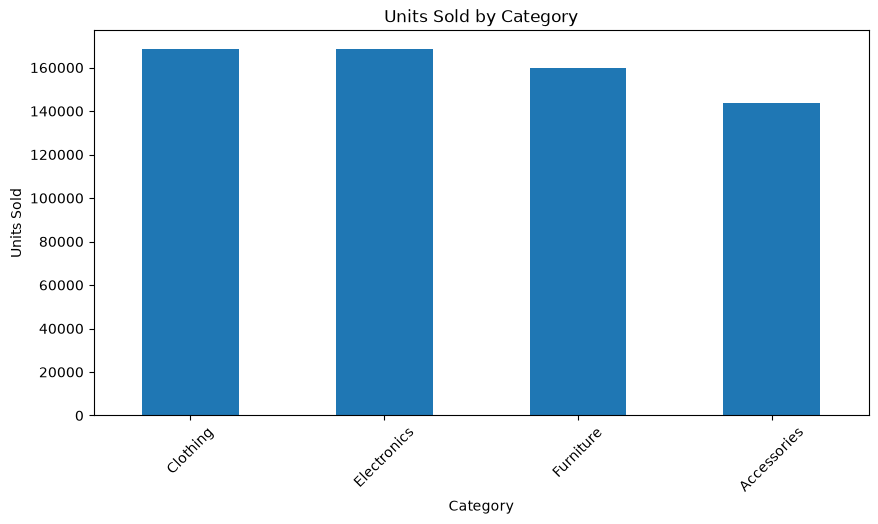

In [29]:
category_sales = df_clean.groupby("Category")["Units Sold"].sum().sort_values(ascending=False)

category_sales.plot(kind="bar", figsize=(10, 5))

plt.title("Units Sold by Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

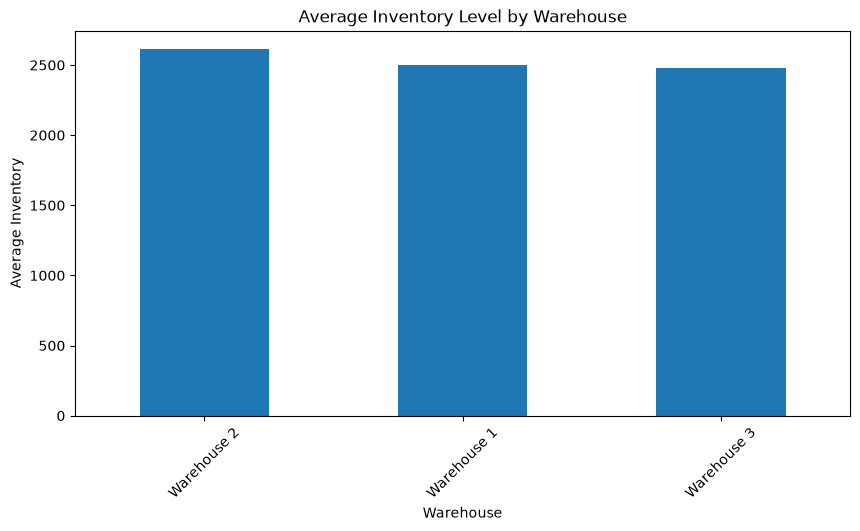

In [30]:
warehouse_inventory = df_clean.groupby("Warehouse")["Inventory Level"].mean().sort_values(ascending=False)

warehouse_inventory.plot(kind="bar", figsize=(10, 5))

plt.title("Average Inventory Level by Warehouse")
plt.xlabel("Warehouse")
plt.ylabel("Average Inventory")
plt.xticks(rotation=45)
plt.show()

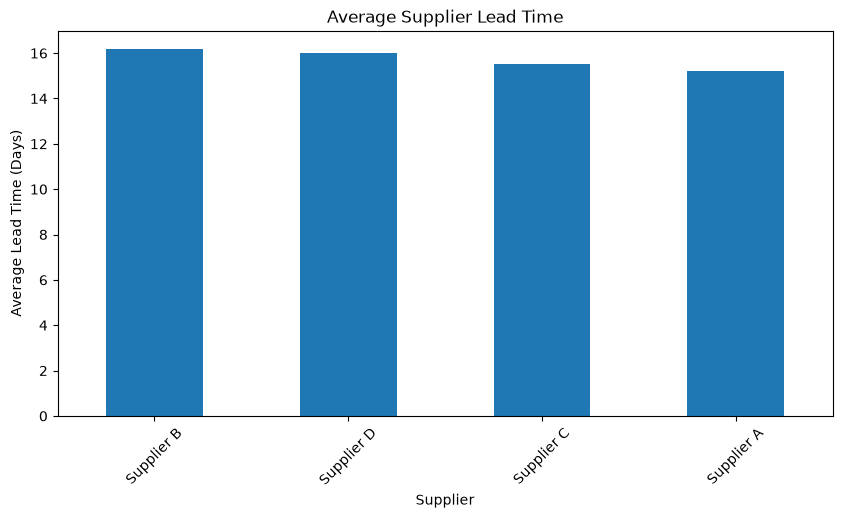

In [31]:
supplier_lead_time = df_clean.groupby("Supplier")["Lead Time (Days)"].mean().sort_values(ascending=False)

supplier_lead_time.plot(kind="bar", figsize=(10, 5))

plt.title("Average Supplier Lead Time")
plt.xlabel("Supplier")
plt.ylabel("Average Lead Time (Days)")
plt.xticks(rotation=45)
plt.show()

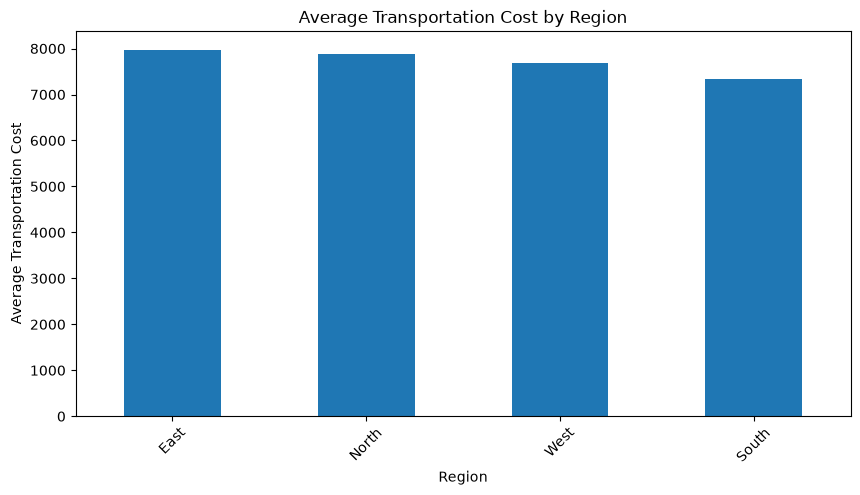

In [32]:
transport_cost = df_clean.groupby("Region")["Transportation Cost"].mean().sort_values(ascending=False)

transport_cost.plot(kind="bar", figsize=(10, 5))

plt.title("Average Transportation Cost by Region")
plt.xlabel("Region")
plt.ylabel("Average Transportation Cost")
plt.xticks(rotation=45)
plt.show()

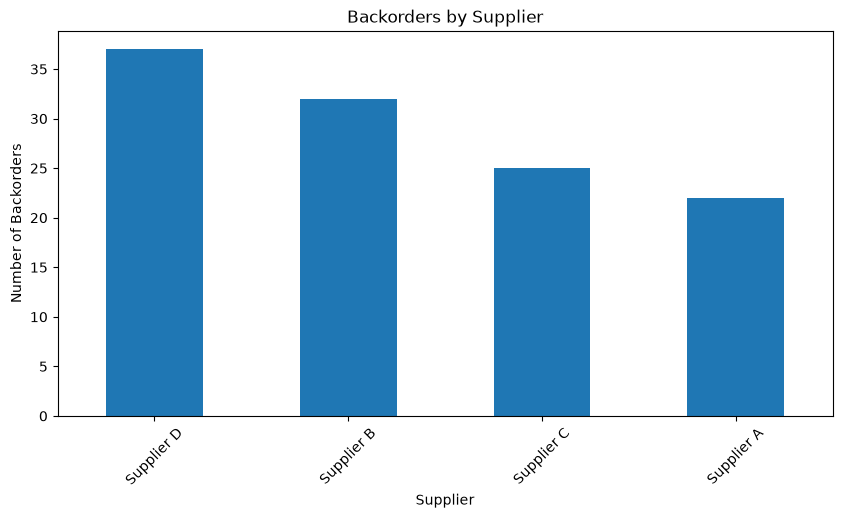

In [33]:
backorders = df_clean.groupby("Supplier")["Backorder"].sum().sort_values(ascending=False)

backorders.plot(kind="bar", figsize=(10, 5))

plt.title("Backorders by Supplier")
plt.xlabel("Supplier")
plt.ylabel("Number of Backorders")
plt.xticks(rotation=45)
plt.show()

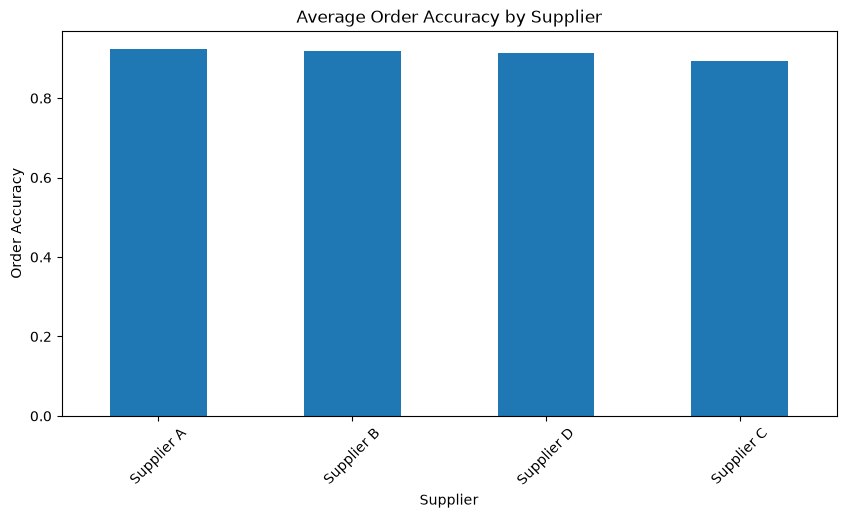

In [34]:
order_accuracy = df_clean.groupby("Supplier")["Order Accuracy"].mean().sort_values(ascending=False)

order_accuracy.plot(kind="bar", figsize=(10, 5))

plt.title("Average Order Accuracy by Supplier")
plt.xlabel("Supplier")
plt.ylabel("Order Accuracy")
plt.xticks(rotation=45)
plt.show()

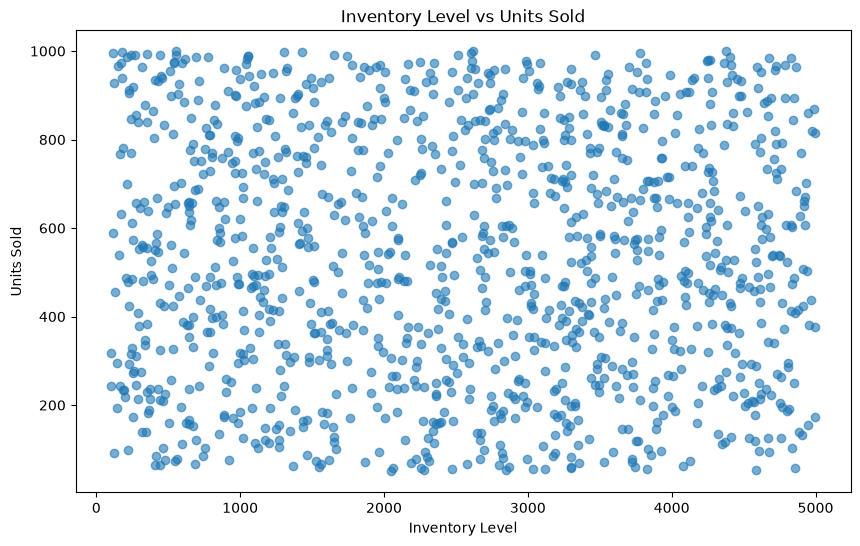

In [35]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_clean["Inventory Level"],
    df_clean["Units Sold"],
    alpha=0.6
)

plt.title("Inventory Level vs Units Sold")
plt.xlabel("Inventory Level")
plt.ylabel("Units Sold")

plt.show()

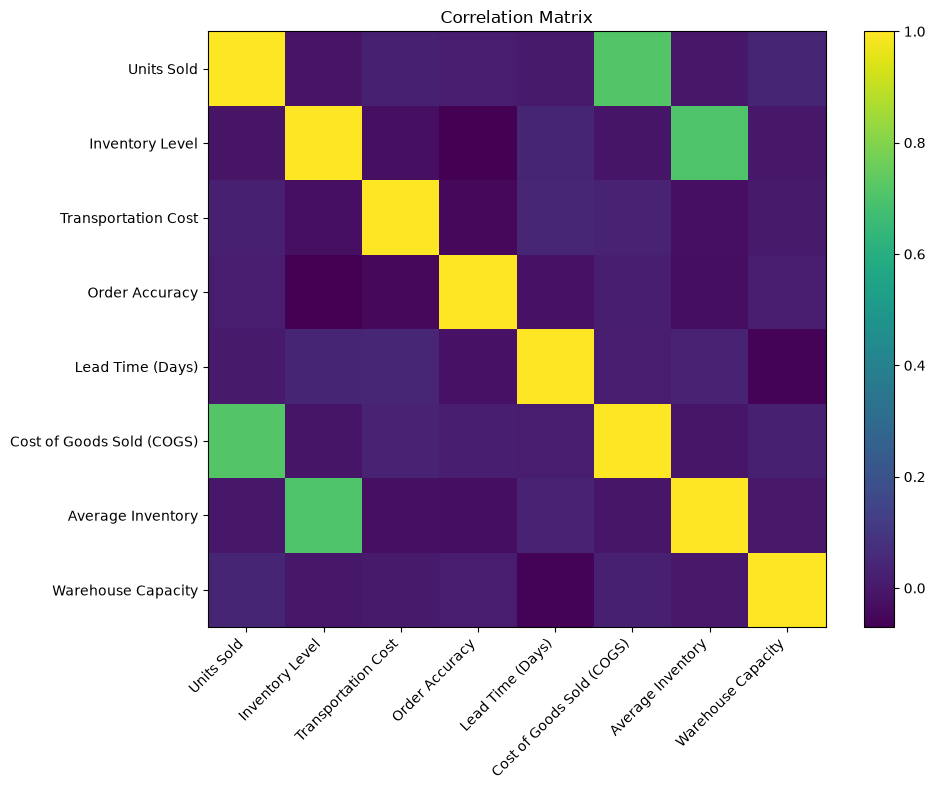

In [37]:
numeric_cols = [
    "Units Sold",
    "Inventory Level",
    "Transportation Cost",
    "Order Accuracy",
    "Lead Time (Days)",
    "Cost of Goods Sold (COGS)",
    "Average Inventory",
    "Warehouse Capacity"
]

correlation = df_clean[numeric_cols].corr()

plt.figure(figsize=(10, 8))

plt.imshow(correlation, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(numeric_cols)),
    numeric_cols,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(numeric_cols)),
    numeric_cols
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [38]:
df_sql = df_clean.copy()

df_sql.columns = (
    df_sql.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

print(df_sql.columns.tolist())

['date', 'region', 'category', 'supplier', 'warehouse', 'order_status', 'units_sold', 'inventory_level', 'transportation_cost', 'order_accuracy', 'lead_time_days', 'backorder', 'cost_of_goods_sold_cogs', 'average_inventory', 'warehouse_capacity']


In [39]:
df_sql.to_csv("Supply_Chain_Final.csv", index=False)

print("File saved successfully!")
print(df_sql.shape)

File saved successfully!
(1200, 15)


In [40]:
import os

print(os.getcwd())
print(os.path.exists("Supply_Chain_Final.csv"))

C:\Users\krith
True


In [41]:
import os

print(os.path.abspath("Supply_Chain_Final.csv"))

C:\Users\krith\Supply_Chain_Final.csv
